### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

============================================================================================================================================================================

**Author:** Rama Nuti

**Course:** UC Berkeley Professional Certificate in Machine Learning and AI

## Project Objective

The goal of this analysis is to identify the factors that influence whether a driver accepts or rejects a coupon while driving. Using exploratory data analysis, visualizations, and statistical summaries, 
this project investigates customer demographics, driving context, and coupon characteristics to determine which factors are associated with higher coupon acceptance rates.

## 1. Business Understanding

Businesses often send mobile coupons to drivers who are traveling near restaurants, coffee houses, and bars. However, not every customer accepts these offers.

The objective of this analysis is to answer the following questions:

- What percentage of customers accept coupons?
- Which coupon types are most frequently accepted?
- What factors influence acceptance of bar coupons?
- What factors influence acceptance of coffee house coupons?
- How can businesses improve coupon targeting strategies?

The findings from this analysis can help businesses improve marketing effectiveness and increase coupon redemption rates.

## 2. Data Loading

The dataset was obtained from the UCI Machine Learning Repository and contains survey responses describing driving scenarios and customer decisions regarding coupon acceptance.

The target variable is:

- Y = 1 --> Coupon Accepted
- Y = 0 --> Coupon Rejected

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('data/coupons.csv')

In [5]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

## 3. Data Cleaning and Missing Value Analysis

Before beginning the analysis, the dataset was examined for missing values and data quality issues.

The car column contains a large number of missing values and will be removed from the analysis. Remaining missing observations will be dropped.

In [6]:
# Dataset information
data.info()

# Missing values count
missing_values = data.isnull().sum()

print(missing_values[missing_values > 0])

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

3. Decide what to do about your missing data -- drop, replace, other...

In [7]:
# Fill missing values with the mean of the respective columns
# Drop car column
data = data.drop(columns=['car'])

# Drop remaining rows with missing values
data = data.dropna()

print(data.shape)

(12079, 25)


4. What proportion of the total observations chose to accept the coupon?



## 4. Overall Coupon Acceptance Analysis

The first step is to determine the overall percentage of customers who accepted coupons.

In [8]:
# 1 = accepted coupon
# 0 = rejected coupon

acceptance_rate = data['Y'].mean()

print(f"Acceptance Rate: {acceptance_rate:.2%}")

Acceptance Rate: 56.93%


5. Use a bar plot to visualize the `coupon` column.

## 5. Coupon Type Distribution

This visualization shows the distribution of coupon types within the dataset.

### Interpretation

Coffee House coupons are the most common coupon type in the dataset. Bar coupons account for a smaller proportion of observations.

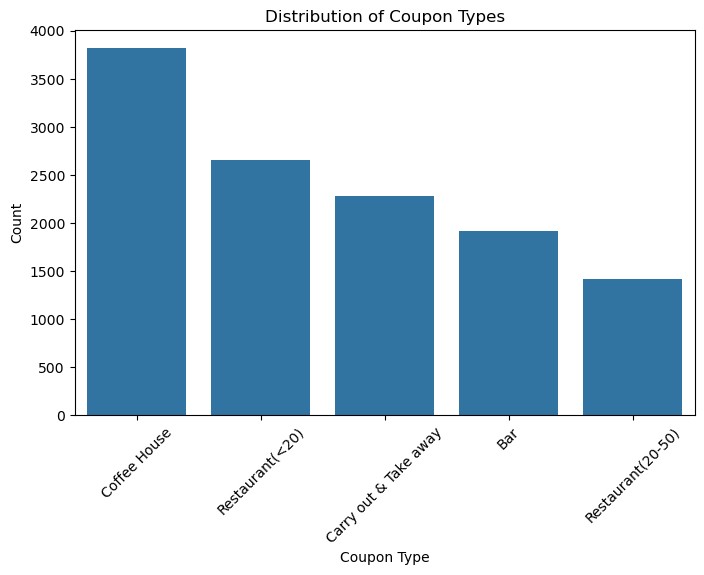

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(data=data,
              x='coupon',
              order=data['coupon'].value_counts().index)

plt.xticks(rotation=45)
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')

plt.show()

6. Use a histogram to visualize the temperature column.

## 6. Temperature Distribution

Temperature is one of the contextual factors included in the dataset.

### Interpretation

The dataset contains observations collected at three temperature levels: 30°F, 55°F, and 80°F.

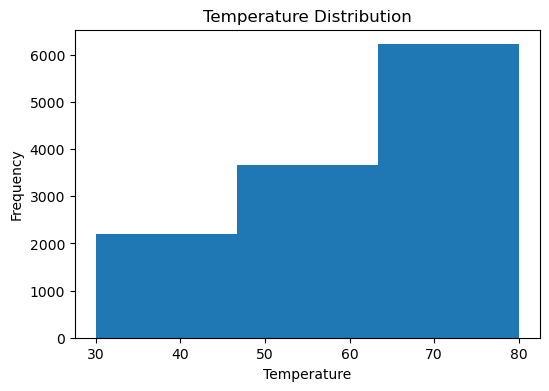

In [10]:
plt.figure(figsize=(6,4))

plt.hist(data['temperature'], bins=3)

plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Frequency')

plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


## 7. Bar Coupon Investigation

Bar coupons were selected for detailed analysis to determine which customer characteristics are associated with higher acceptance rates.


In [11]:
bar_df = data[data['coupon'] == 'Bar']

bar_df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,1,0,0


2. What proportion of bar coupons were accepted?


    
## 7.1 Bar Coupon Acceptance Rate

In [12]:
# Proportion of Bar Coupons Accepted

bar_acceptance_rate = bar_df['Y'].mean()

print(f"Bar Coupon Acceptance Rate: {bar_acceptance_rate:.2%}")


Bar Coupon Acceptance Rate: 41.19%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


## 7.2 Acceptance by Bar Visit Frequency

In [ ]:
# Compare Acceptance Based on Bar Visits

# Group-1 : More than 3 visits
frequent_bar = bar_df[bar_df['Bar'].isin(['4~8', 'gt8'])]
frequent_rate = frequent_bar['Y'].mean()
print(f"Frequent Bar Coupon Acceptance Rate: {frequent_rate:.2%}")

# Group-2 : 3 or fewer visits
infrequent_bar = bar_df[~bar_df['Bar'].isin(['4~8', 'gt8'])]
infrequent_rate = infrequent_bar['Y'].mean()
print(f"Infrequent Bar Coupon Acceptance Rate: {infrequent_rate:.2%}")

Frequent Bar Coupon Acceptance Rate: 76.17%
Infrequent Bar Coupon Acceptance Rate: 37.27%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [14]:
# Drivers Who Go to Bars More Than Once a Month and Are Over 25

group1 = bar_df[
    (bar_df['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (~bar_df['age'].isin(['below21', '21']))
]

group2 = bar_df.drop(group1.index)

print(group1['Y'].mean())
print(group2['Y'].mean())

# Older drivers who already visit bars are significantly more likely to accept bar coupons.

0.6898263027295285
0.33774834437086093


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


## 7.3 Acceptance by Passenger Type

In [15]:
# More Than Once a Month + No Kids + Not Farming/Fishing/Forestry

group = bar_df[
    (bar_df['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_df['passanger'] != 'Kid(s)') &
    (bar_df['occupation'] != 'Farming Fishing & Forestry')
]

group['Y'].mean() 

print(f"Acceptance Rate for Frequent Bar Visitors without Kids and Not in Farming/Fishing/Forestry: {group['Y'].mean():.2%}")

#  Acceptance rate increases further among this group.

Acceptance Rate for Frequent Bar Visitors without Kids and Not in Farming/Fishing/Forestry: 70.94%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



## 7.4 Acceptance by Age Group and Acceptance by Income

In [ ]:
# Group-1 : Frequent Bar Visitors without Kids and Not in Farming/Fishing/Forestry
group1_condition = (
        (bar_df['Bar'].isin(['1~3','4~8','gt8'])) &
        (bar_df['passanger'] != 'Kid(s)') &
        (bar_df['maritalStatus'] != 'Widowed')
    )

group1_acceptance_rate = bar_df[group1_condition]['Y'].mean()
print(f"Group 1 Acceptance Rate: {group1_acceptance_rate:.2%}")

group2_condition = (
        (bar_df['Bar'].isin(['1~3','4~8','gt8'])) &
        (bar_df['age'].isin(['below21','21','26','26~30']))
    )

group2_acceptance_rate = bar_df[group2_condition]['Y'].mean()
print(f"Group 2 Acceptance Rate: {group2_acceptance_rate:.2%}")

group3_condition = (
        (bar_df['RestaurantLessThan20'].isin(['4~8','gt8'])) &
        (bar_df['income'].isin([
            'Less than $12500',
            '$12500 - $24999',
            '$25000 - $37499',
            '$37500 - $49999'
        ]))
    )

group3_acceptance_rate = bar_df[group3_condition]['Y'].mean()
print(f"Group 3 Acceptance Rate: {group3_acceptance_rate:.2%}")


groups_condition = (group1_condition | group2_condition | group3_condition)
groups_acceptance_rate = bar_df[groups_condition]['Y'].mean()
print(f"Groups Acceptance Rate: {groups_acceptance_rate:.2%}")

Group 1 Acceptance Rate: 70.94%
Group 2 Acceptance Rate: 71.95%
Group 3 Acceptance Rate: 45.65%
Groups Acceptance Rate: 58.71%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
# Assumptions:
bar_df = data[data['coupon'] == 'Bar']

# 1. Overall Bar Coupon Acceptance Rate
overall_acceptance_rate = bar_df['Y'].mean()
print(f"Overall Bar Coupon Acceptance Rate: {overall_acceptance_rate:.2%}")

#2. Drivers Who Visit Bars Frequently  
frequent_bar = bar_df[bar_df['Bar'].isin(['1~3', '4~8', 'gt8'])]
frequent_rate = frequent_bar['Y'].mean()
print(f"Frequent Bar Visitors Acceptance Rate: {frequent_rate:.2%}")

#3. Younger Adults (Under 30)
young_drivers = bar_df[bar_df['age'].isin(['below21', '21', '26'])]
young_rate = young_drivers['Y'].mean()
print(f"Young Drivers Acceptance Rate: {young_rate:.2%}")

# Use below
young_drivers = bar_df[bar_df['age'].isin(['below21','21','21~25','26~30'])]

#4. Drivers Without Children in Vehicle
no_kids = bar_df[ bar_df['passanger'] != 'Kid(s)']
no_kids_rate = no_kids['Y'].mean()
print(f"No Kids Passenger Acceptance Rate: {no_kids_rate:.2%}")

#5. Not Widowed Drivers
not_widowed = bar_df[ bar_df['maritalStatus'] != 'Widowed']
not_widowed_rate = not_widowed['Y'].mean()
print(f"Not Widowed Drivers Acceptance Rate: {not_widowed_rate:.2%}")

#6. Frequently Eat at Cheap Restaurants
# Assuming "RestaurantLessThan20" indicates frequency of eating at cheap restaurants
# This is a proxy for drivers who might be more price-sensitive and thus more likely to accept coupons
# We will calculate the acceptance rate for drivers who eat at cheap restaurants frequently
# We will consider "4~8" and "gt8" as frequent eaters at cheap restaurants
frequent_cheap_eaters = bar_df[bar_df['RestaurantLessThan20'].isin(['4~8', 'gt8'])]
frequent_cheap_eaters_rate = frequent_cheap_eaters['Y'].mean()
print(f"Frequent Cheap Restaurant Eaters Acceptance Rate: {frequent_cheap_eaters_rate:.2%}")

#7.Lower-to-Middle Income Drivers
# Assuming "income" indicates the income level of drivers
# We will calculate the acceptance rate for drivers in the lower-to-middle income brackets
# We will consider "Less than $12500", "$12500 - $24999", "$25000 - $37499", and "$37500 - $49999" as lower-to-middle income brackets
lower_middle_income = bar_df[bar_df['income'].isin([
    'Less than $12500',
    '$12500 - $24999',
    '$25000 - $37499',
    '$37500 - $49999'
])]
lower_middle_income_rate = lower_middle_income['Y'].mean()
print(f"Lower-to-Middle Income Drivers Acceptance Rate: {lower_middle_income_rate:.2%}")

#8. Traveling With Friends or Partners
# Assuming "passanger" indicates the type of passengers in the vehicle
# We will calculate the acceptance rate for drivers traveling with friends or partners
# We will consider "Friend(s)" and "Partner" as traveling with friends or partners
traveling_with_friends_partners = bar_df[bar_df['passanger'].isin(['Friend(s)', 'Partner'])]
traveling_with_friends_partners_rate = traveling_with_friends_partners['Y'].mean()
print(f"Traveling With Friends or Partners Acceptance Rate: {traveling_with_friends_partners_rate:.2%}")

# Create a Summary Table - Easy to analyze and compare the acceptance rates across different groups in a structured format. 
# This allows for quick identification of which groups are more likely to accept bar coupons, aiding in targeted marketing strategies.
summary = pd.DataFrame({
    'Group': [
        'Overall',
        'Frequent Bar Visitors',
        'Young Drivers',
        'No Kids',
        'Not Widowed',
        'Frequent Restaurant Visitors',
        'Lower Income',
        'Friends/Partner'
    ],
    'Acceptance Rate': [
        overall_acceptance_rate,
        frequent_rate,
        young_rate,
        no_kids_rate,
        not_widowed_rate,
        frequent_cheap_eaters_rate,
        lower_middle_income_rate,
        traveling_with_friends_partners_rate
    ]
})

summary['Acceptance Rate'] = (summary['Acceptance Rate'] * 100).round(2)

print(summary)
                                                             

Overall Bar Coupon Acceptance Rate: 41.19%
Frequent Bar Visitors Acceptance Rate: 68.53%
Young Drivers Acceptance Rate: 48.82%
No Kids Passenger Acceptance Rate: 43.51%
Not Widowed Drivers Acceptance Rate: 41.19%
Frequent Cheap Restaurant Eaters Acceptance Rate: 42.92%
Lower-to-Middle Income Drivers Acceptance Rate: 42.27%
Traveling With Friends or Partners Acceptance Rate: 48.62%
                          Group  Acceptance Rate
0                       Overall            41.19
1         Frequent Bar Visitors            68.53
2                 Young Drivers            48.82
3                       No Kids            43.51
4                   Not Widowed            41.19
5  Frequent Restaurant Visitors            42.92
6                  Lower Income            42.27
7               Friends/Partner            48.62


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

# 8. Independent Investigation: Coffee House Coupons

Coffee House coupons were selected for independent analysis to identify characteristics associated with acceptance.

## 8.1 Coffee House Coupon Acceptance Rate

In [18]:
# Fill missing values with the mean of the respective columns
# Create Coffee House Dataset
coffee_df = data[data['coupon'] == 'Coffee House']

# Acceptance Rate for Coffee House Coupons
coffee_acceptance_rate = coffee_df['Y'].mean()
print(f"Coffee House Coupon Acceptance Rate: {coffee_acceptance_rate:.2%}")

# Compare Frequent vs Infrequent Coffee Visitors
frequent = coffee_df[ coffee_df['CoffeeHouse'].isin(['4~8','gt8'])]
infrequent = coffee_df[~coffee_df['CoffeeHouse'].isin(['4~8','gt8'])]

print(frequent['Y'].mean())
print(infrequent['Y'].mean())


Coffee House Coupon Acceptance Rate: 49.63%
0.6725559481743227
0.44590495449949447


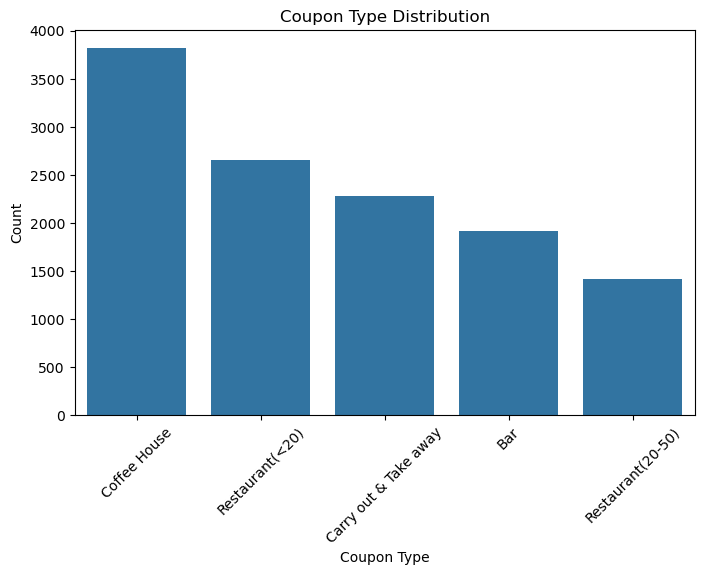

In [19]:
# 1. Count Plot (Categorical Data)
# Best for: Coupon Types / Passenger Types / Weather / Gender

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x='coupon',
    order=data['coupon'].value_counts().index
)

plt.title('Coupon Type Distribution')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()


## 8.2 Acceptance by Coffee House Visit Frequency

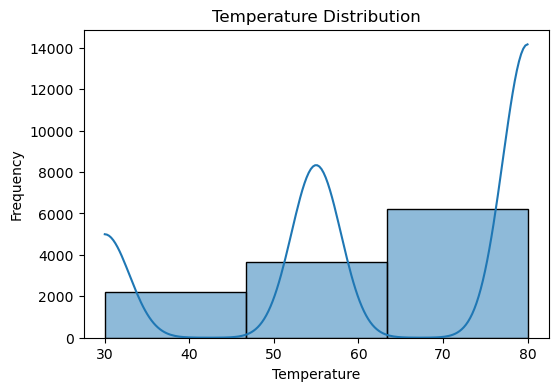

In [20]:
# Histogram (Continuous Data)
# Best for: Temperature / Numerical variables

plt.figure(figsize=(6,4))

sns.histplot(
    data=data,
    x='temperature',
    bins=3,
    kde=True
)

plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Frequency')

plt.show()

### 8.3 Other helpful visualizations and plots for categorical variables

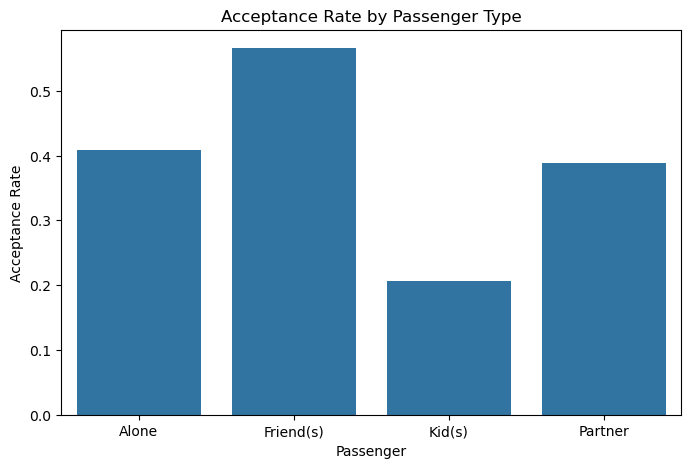

In [21]:
# Bar Plot
# Best for: Acceptance Rate by Group

bar_acceptance = (
    bar_df.groupby('passanger')['Y']
          .mean()
          .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=bar_acceptance,
    x='passanger',
    y='Y'
)

plt.title('Acceptance Rate by Passenger Type')
plt.xlabel('Passenger')
plt.ylabel('Acceptance Rate')

plt.show()


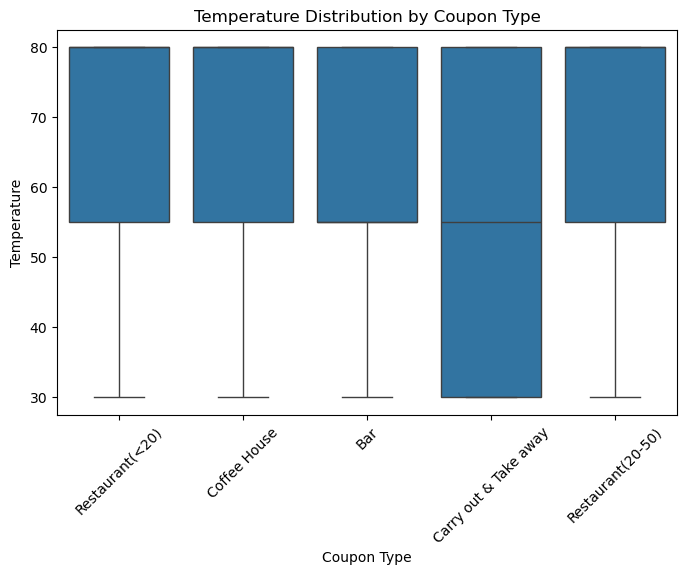

In [22]:
# Box Plot
# Best for: Distribution comparison / Detecting outliers

plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x='coupon',
    y='temperature'
)

plt.title('Temperature Distribution by Coupon Type')
plt.xlabel('Coupon Type')
plt.ylabel('Temperature')

plt.xticks(rotation=45)

plt.show()



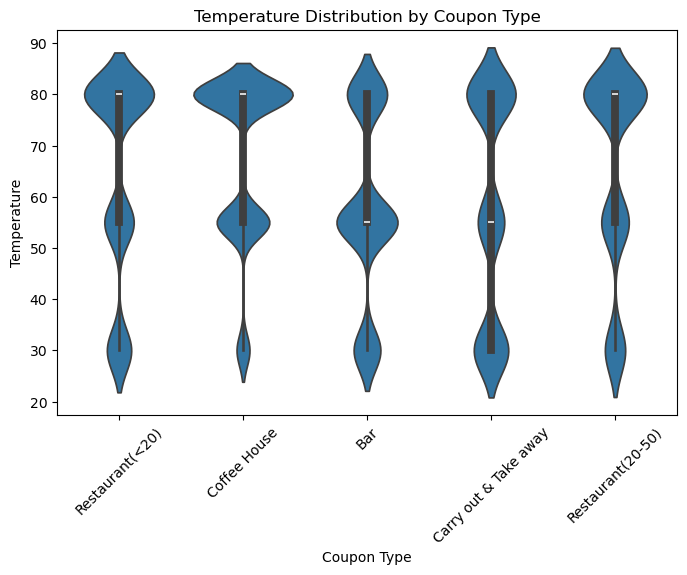

In [23]:
# Violin Plot
# Best for: Showing distribution shape, median, and density

plt.figure(figsize=(8,5))

sns.violinplot(
    data=data,
    x='coupon',
    y='temperature'
)

plt.title('Temperature Distribution by Coupon Type')
plt.xlabel('Coupon Type')
plt.ylabel('Temperature')

plt.xticks(rotation=45)

plt.show()


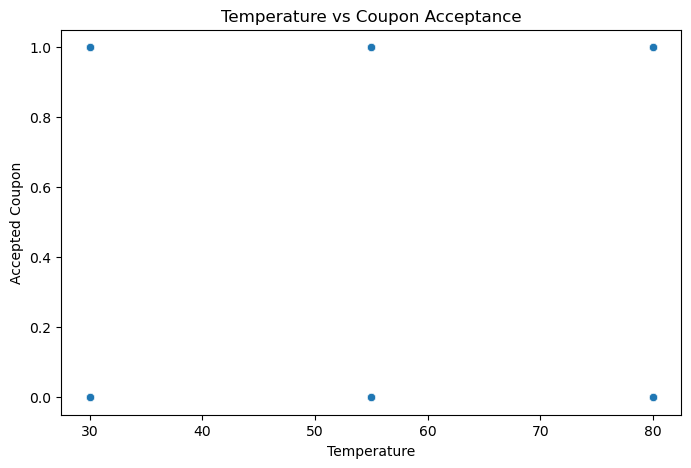

In [24]:
# Scatter Plot
# Best for: Relationship between two numeric variables

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x='temperature',
    y='Y'
)

plt.title('Temperature vs Coupon Acceptance')
plt.xlabel('Temperature')
plt.ylabel('Accepted Coupon')

plt.show()


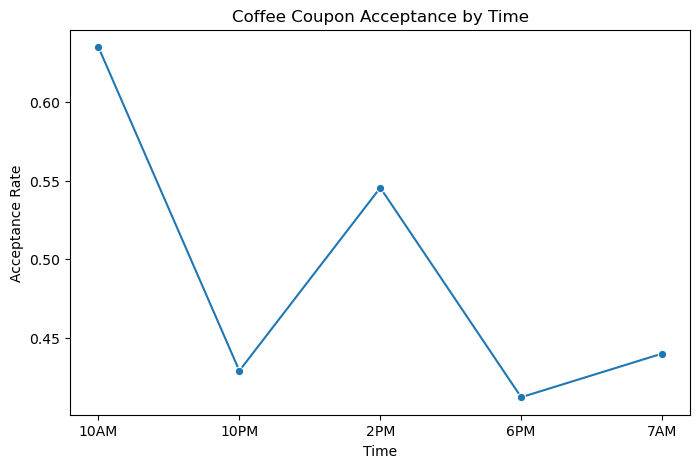

In [25]:
# Line Plot
# Best for: Trends over time or ordered categories

coffee_time = (
    coffee_df.groupby('time')['Y']
             .mean()
             .reset_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=coffee_time,
    x='time',
    y='Y',
    marker='o'
)

plt.title('Coffee Coupon Acceptance by Time')
plt.xlabel('Time')
plt.ylabel('Acceptance Rate')

plt.show()


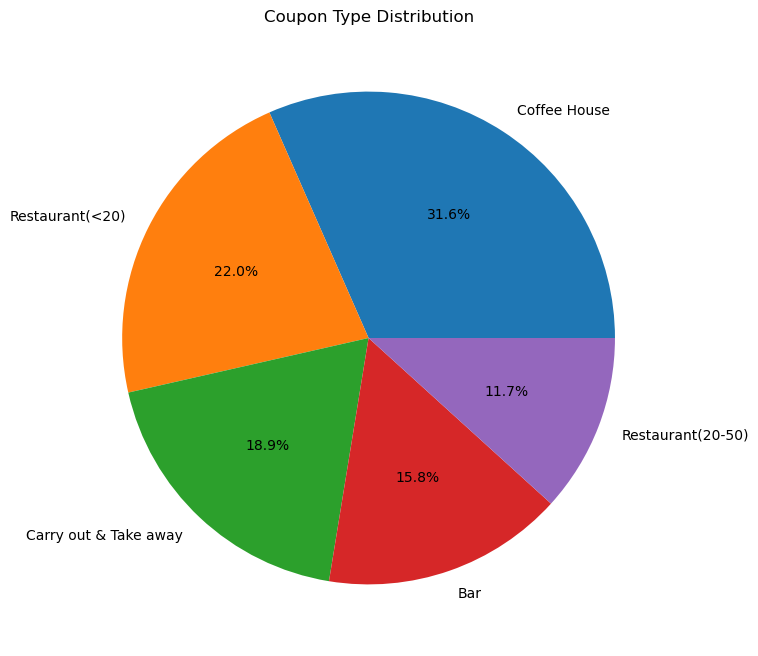

In [26]:
# Pie Chart (Matplotlib)
# Best for: Percentage breakdowns

coupon_counts = data['coupon'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    coupon_counts,
    labels=coupon_counts.index,
    autopct='%1.1f%%'
)

plt.title('Coupon Type Distribution')

plt.show()




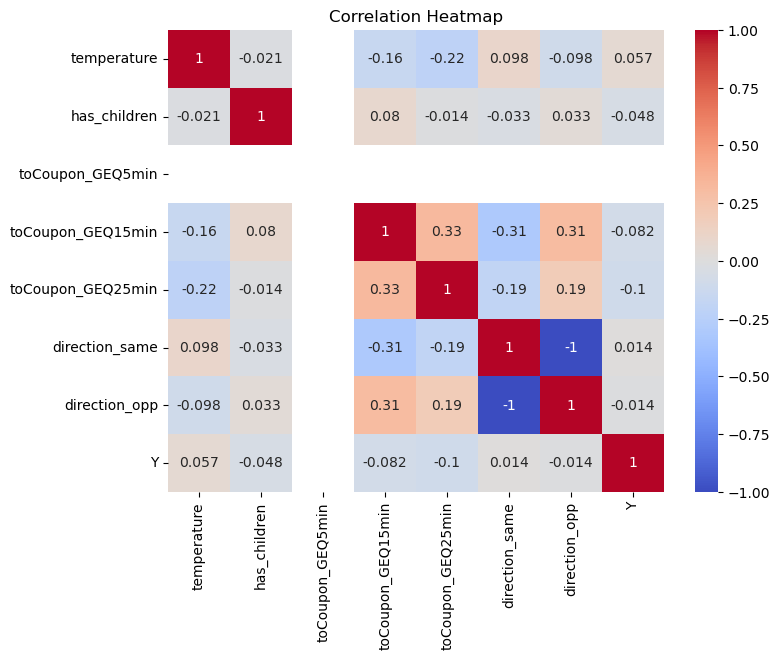

In [27]:
# Heatmap
# Best for: Correlation analysis

numeric_cols = data.select_dtypes(include='number')

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()




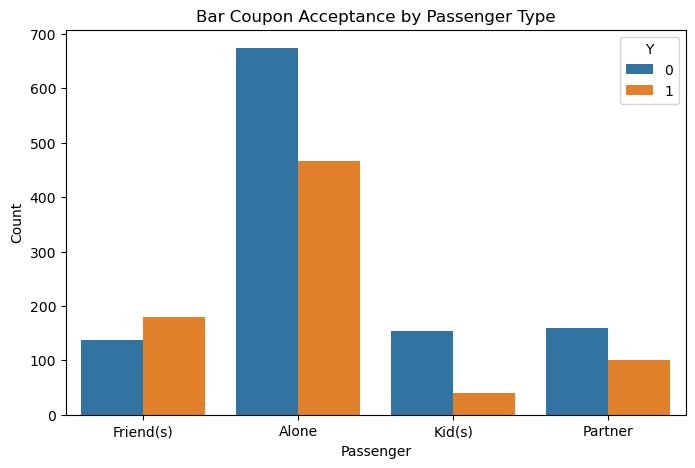

In [28]:
# Stacked Count Plot Using Hue
# Best for: Accepted vs Rejected

plt.figure(figsize=(8,5))

sns.countplot(
    data=bar_df,
    x='passanger',
    hue='Y'
)

plt.title('Bar Coupon Acceptance by Passenger Type')
plt.xlabel('Passenger')
plt.ylabel('Count')

plt.show()




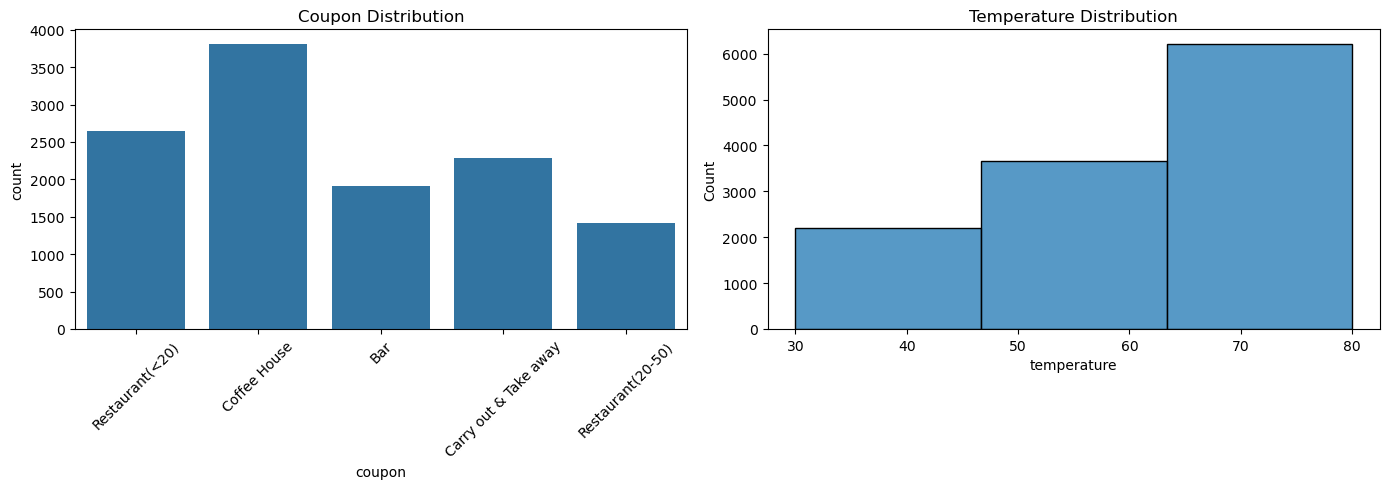

In [29]:
# Subplots (Rubric Bonus)
# Shows multiple visualizations together.

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.countplot(
    data=data,
    x='coupon',
    ax=axes[0]
)

axes[0].set_title('Coupon Distribution')
axes[0].tick_params(axis='x', rotation=45)

sns.histplot(
    data=data,
    x='temperature',
    bins=3,
    ax=axes[1]
)

axes[1].set_title('Temperature Distribution')

plt.tight_layout()
plt.show()


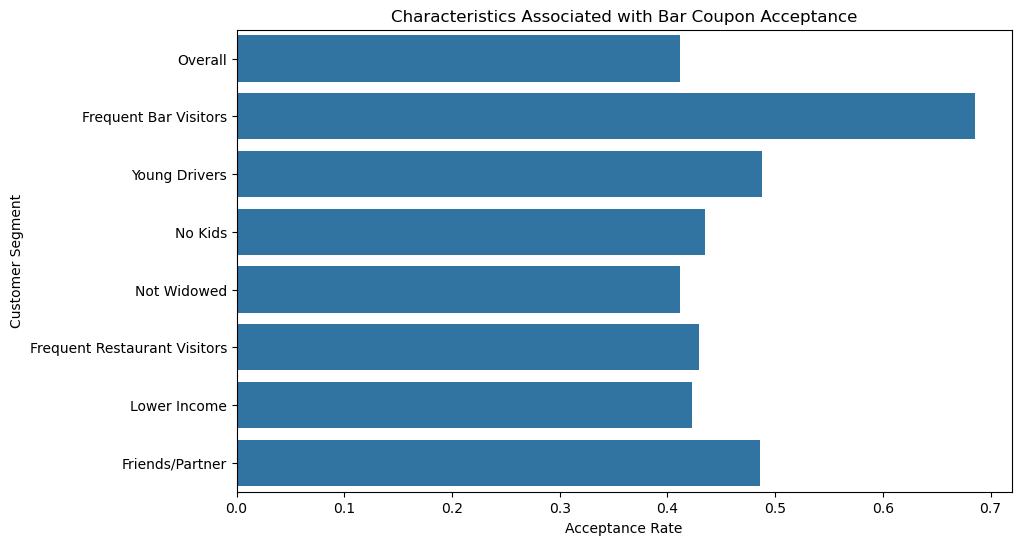

In [30]:
# Best Visualization for Your Findings
# This chart directly supports your conclusions.

summary = pd.DataFrame({
    'Group': [
        'Overall',
        'Frequent Bar Visitors',
        'Young Drivers',
        'No Kids',
        'Not Widowed',
        'Frequent Restaurant Visitors',
        'Lower Income',
        'Friends/Partner'
    ],
    'Acceptance Rate': [
        overall_acceptance_rate,
        frequent_rate,
        young_rate,
        no_kids_rate,
        not_widowed_rate,
        frequent_cheap_eaters_rate,
        lower_middle_income_rate,
        traveling_with_friends_partners_rate
    ]
})

plt.figure(figsize=(10,6))

sns.barplot(
    data=summary,
    x='Acceptance Rate',
    y='Group'
)

plt.title('Characteristics Associated with Bar Coupon Acceptance')
plt.xlabel('Acceptance Rate')
plt.ylabel('Customer Segment')

plt.show()

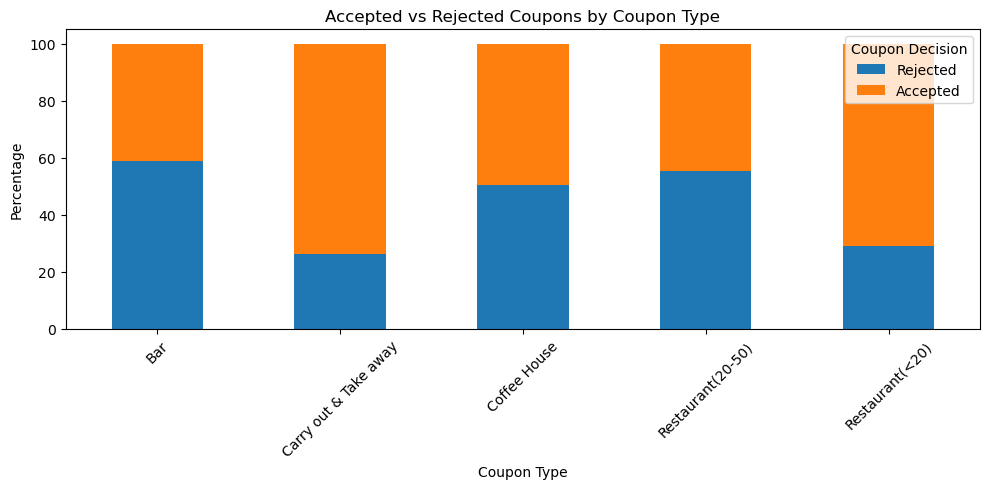

In [31]:
# Stacked Percentage Bar Chart: Accepted vs Rejected by Coupon Type

coupon_acceptance_pct = (
    pd.crosstab(data['coupon'], data['Y'], normalize='index') * 100
)

coupon_acceptance_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.title('Accepted vs Rejected Coupons by Coupon Type')
plt.xlabel('Coupon Type')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(['Rejected', 'Accepted'], title='Coupon Decision')

plt.tight_layout()
plt.show()




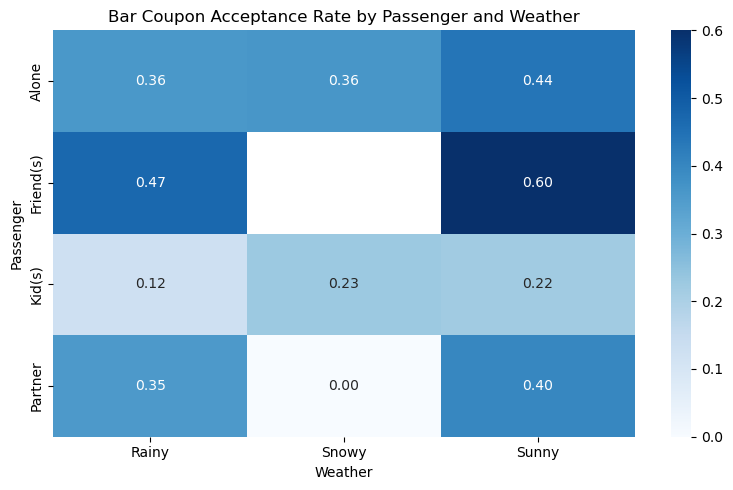

In [32]:
# Heatmap: Acceptance Rate by Passenger and Weather

heatmap_data = bar_df.pivot_table(
    values='Y',
    index='passanger',
    columns='weather',
    aggfunc='mean'
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('Bar Coupon Acceptance Rate by Passenger and Weather')
plt.xlabel('Weather')
plt.ylabel('Passenger')

plt.tight_layout()
plt.show()

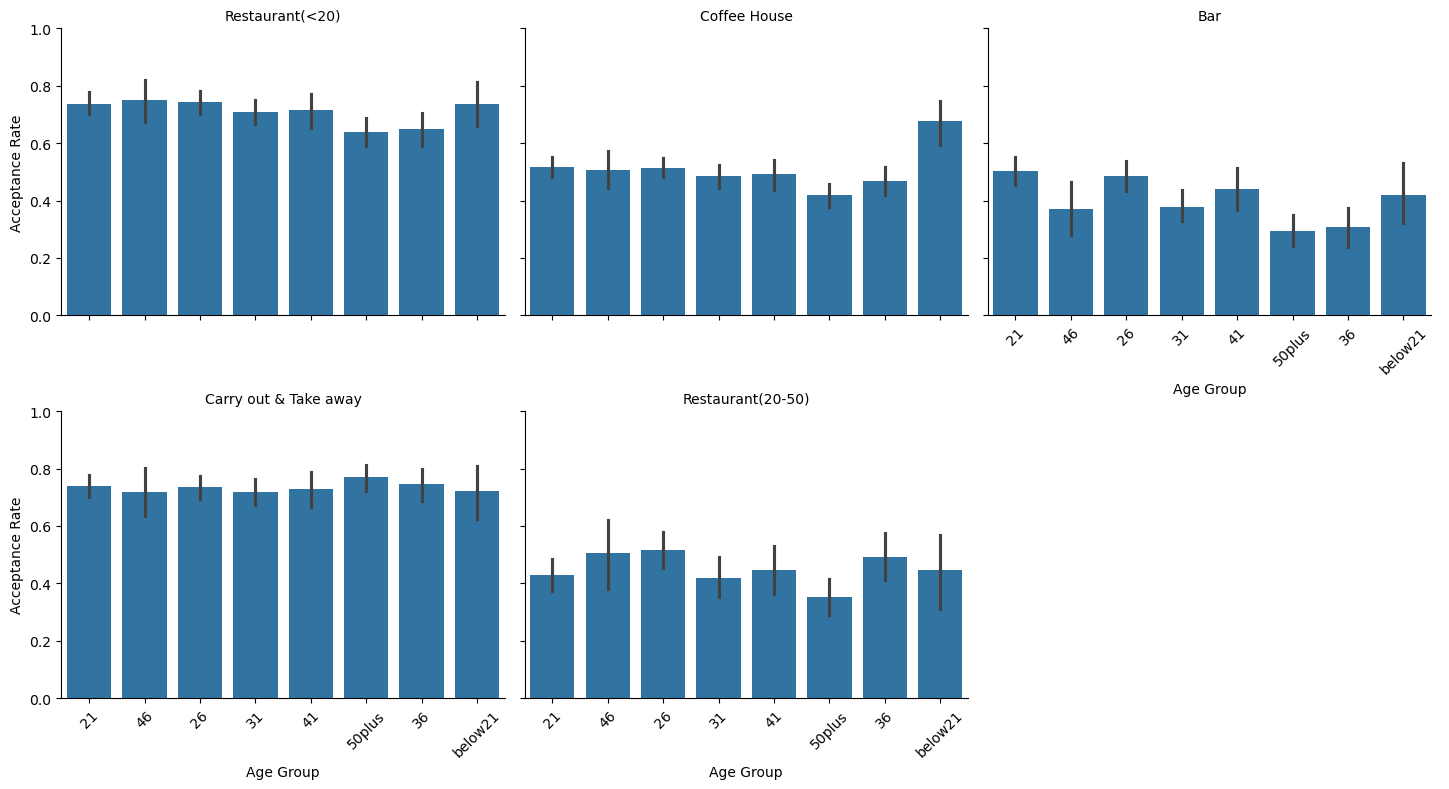

In [33]:
# FacetGrid: Acceptance by Age Across Coupon Types
g = sns.catplot(
    data=data,
    x='age',
    y='Y',
    col='coupon',
    kind='bar',
    col_wrap=3,
    height=4,
    aspect=1.2
)

g.set_titles('{col_name}')
g.set_axis_labels('Age Group', 'Acceptance Rate')

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


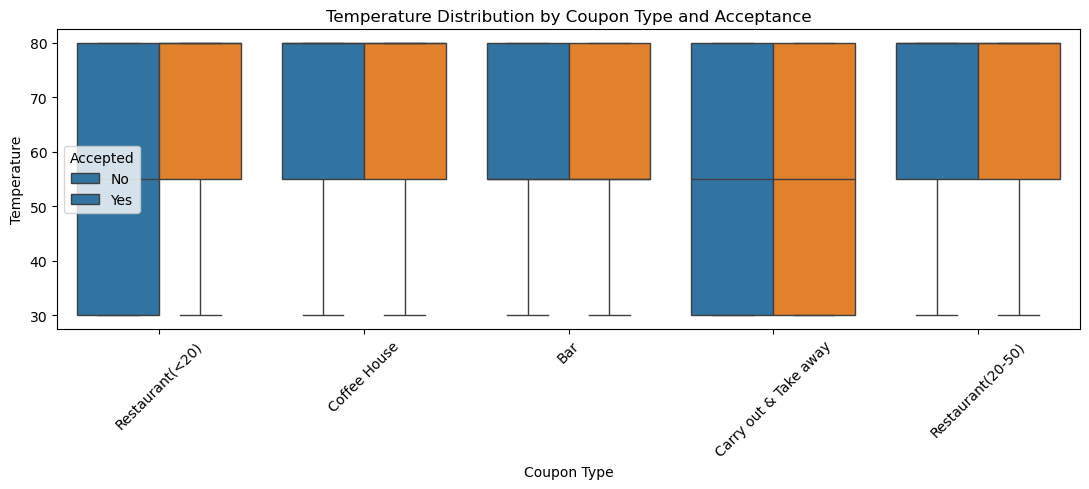

In [34]:
# Box Plot with Hue: Temperature by Coupon Type and Acceptance

plt.figure(figsize=(11, 5))

sns.boxplot(
    data=data,
    x='coupon',
    y='temperature',
    hue='Y'
)

plt.title('Temperature Distribution by Coupon Type and Acceptance')
plt.xlabel('Coupon Type')
plt.ylabel('Temperature')
plt.xticks(rotation=45)
plt.legend(title='Accepted', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

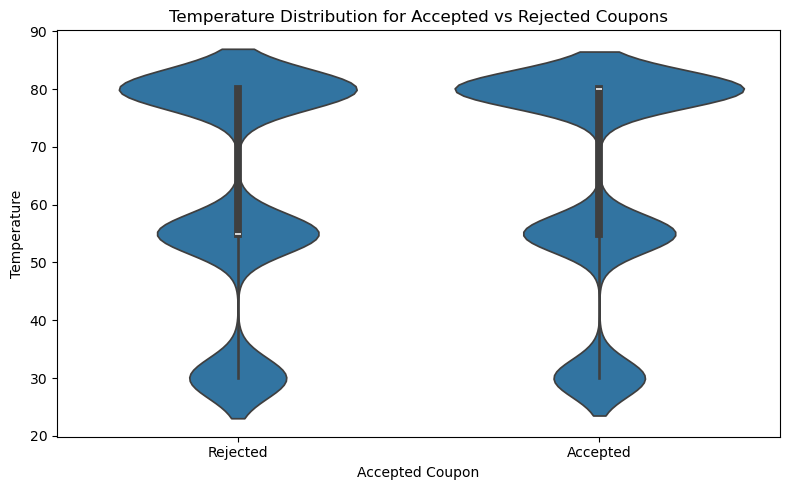

In [35]:
# Violin Plot: Temperature Distribution by Coupon Acceptance

plt.figure(figsize=(8, 5))

sns.violinplot(
    data=data,
    x='Y',
    y='temperature'
)

plt.title('Temperature Distribution for Accepted vs Rejected Coupons')
plt.xlabel('Accepted Coupon')
plt.ylabel('Temperature')
plt.xticks([0, 1], ['Rejected', 'Accepted'])

plt.tight_layout()
plt.show()

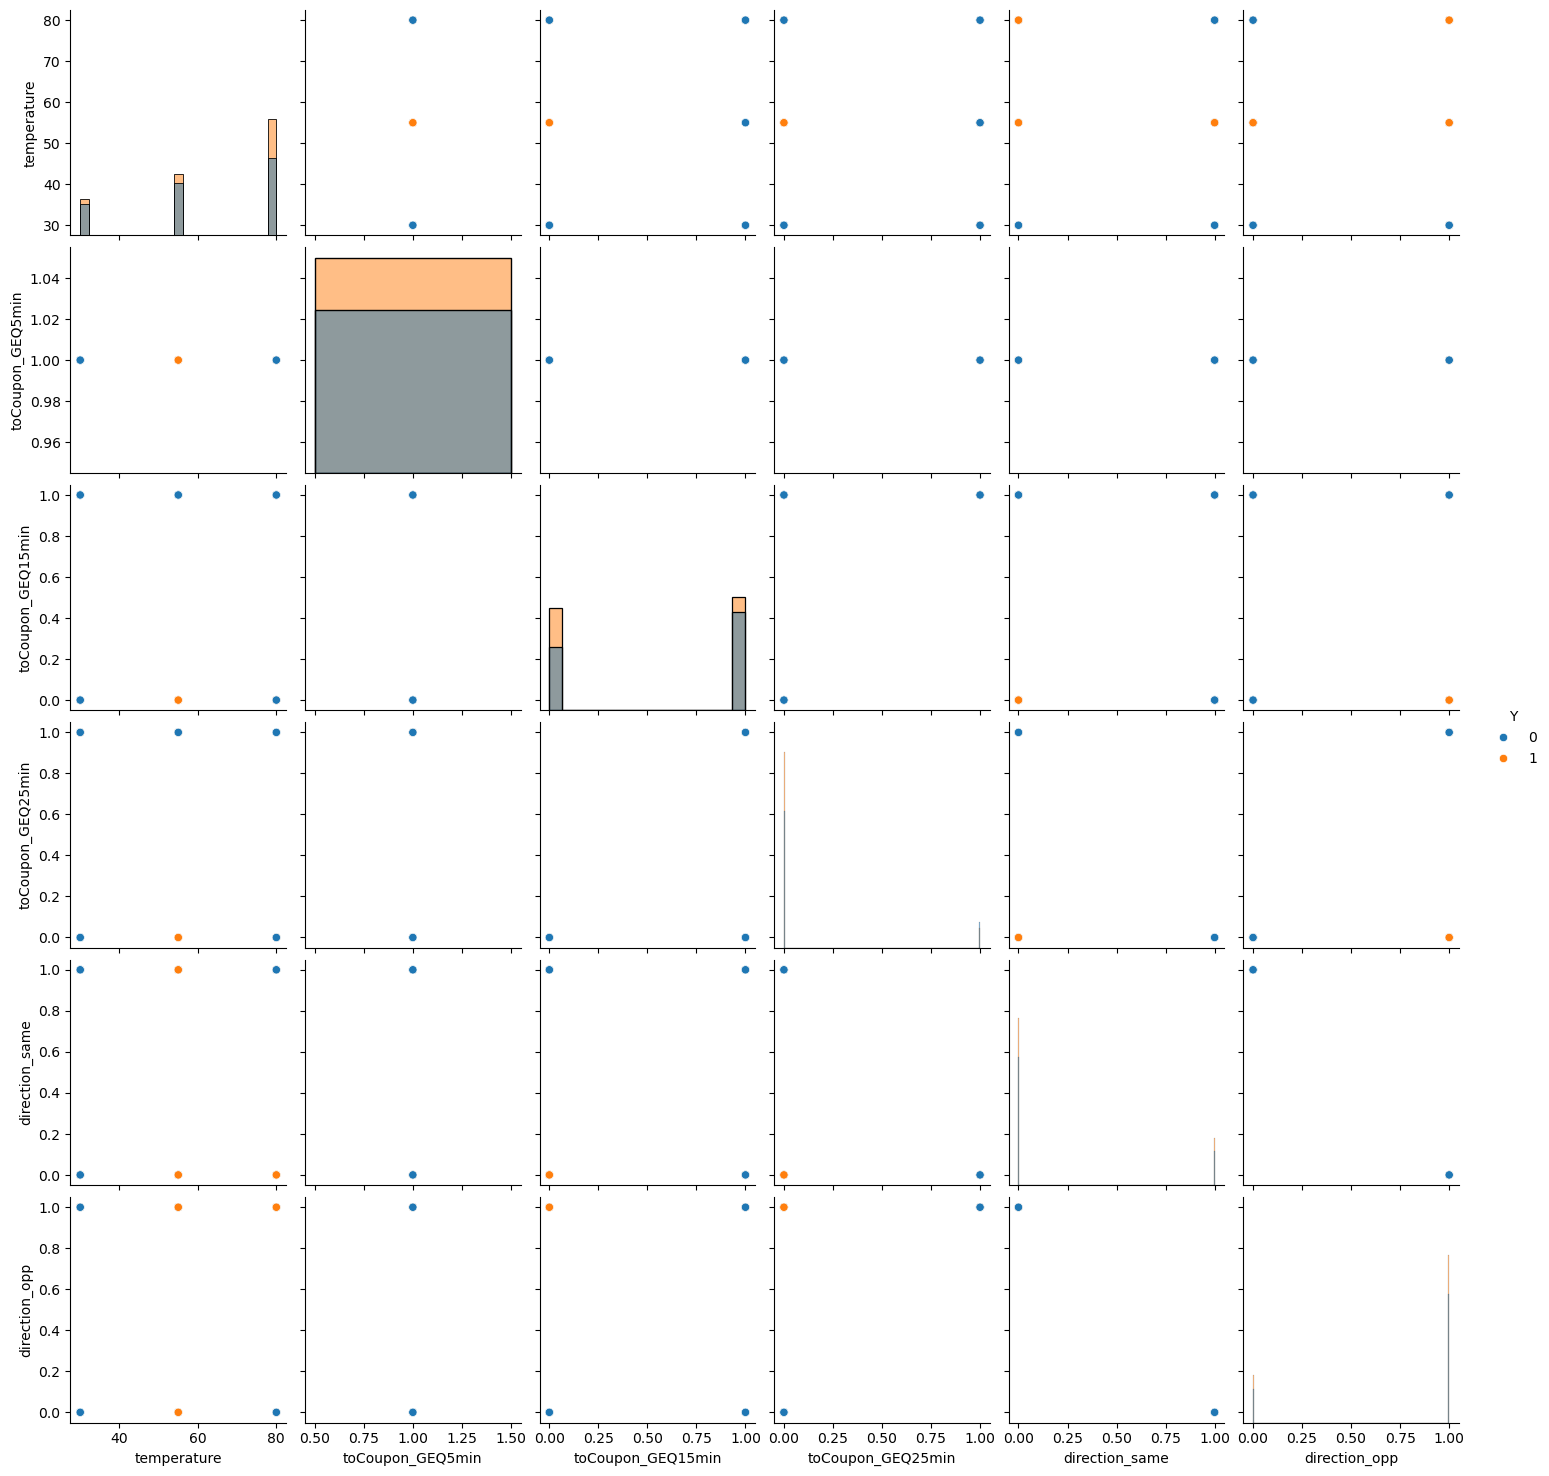

In [36]:
# Pair Plot for Numeric Variables

numeric_data = data[
    ['temperature', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min',
     'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Y']
]

sns.pairplot(
    numeric_data,
    hue='Y',
    diag_kind='hist'
)

plt.show()


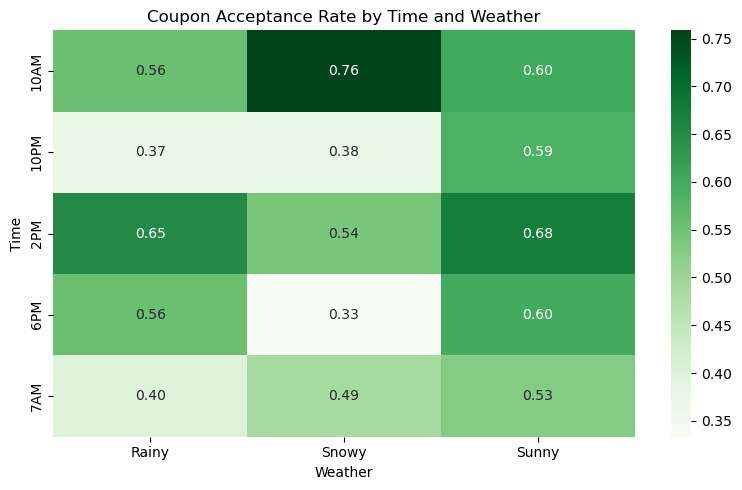

In [37]:
# Acceptance Rate Heatmap by Time and Weather

time_weather = data.pivot_table(
    values='Y',
    index='time',
    columns='weather',
    aggfunc='mean'
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    time_weather,
    annot=True,
    fmt='.2f',
    cmap='Greens'
)

plt.title('Coupon Acceptance Rate by Time and Weather')
plt.xlabel('Weather')
plt.ylabel('Time')

plt.tight_layout()
plt.show()

# 9. Key Findings

The analysis identified several factors associated with coupon acceptance.

### Bar Coupons

- Frequent bar visitors have the highest acceptance rates.
- Younger drivers are more likely to accept bar coupons.
- Drivers traveling with friends or partners show higher acceptance rates.
- Customers who frequently dine out are more responsive to promotions.

### Coffee House Coupons

- Previous coffee house visitation is the strongest predictor of acceptance.
- Flexible travel situations increase acceptance rates.

### Overall Insight

Customer behavior is a stronger predictor of coupon acceptance than demographic characteristics alone.

# 10. Actionable Recommendations

Based on the findings:

1. Target bar coupons toward customers who already visit bars.
2. Prioritize social travel situations for bar promotions.
3. Focus coffee house coupons on regular coffee consumers.
4. Use behavioral history as the primary targeting mechanism.
5. Reduce marketing spend on customer groups with historically low acceptance rates.

# 11. Conclusion

This analysis examined the factors influencing coupon acceptance behavior.

The results show that previous customer behavior is the strongest predictor of acceptance. Customers are significantly more likely to accept coupons for businesses they already visit regularly.

Future work could include predictive modeling, statistical hypothesis testing, and deeper analysis of additional coupon categories.